# I - Preamble

**May 2026 - Ana Rita Carvalho**

(ana.rita.carvalho@tecnico.ulisboa.pt)

This notebook uses Energy Flow Polynomials in different classification models. The datasets used for computing the EFPs and training the models correspond to a dijet background and a di-higgs hh-4b signal (available [here](https://data.mendeley.com/datasets/v9z86dp9mv/1))

In [ ]:
# Install uproot and awkward array package
!pip install uproot awkward

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.5/397.5 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 28.2 MB/s eta 0:00:00


In [ ]:
# Install EnergyFlow package
!pip install energyflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.8/700.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.2/503.2 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 39.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 

In [ ]:
# Install vector package
!pip install vector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 6.5 MB/s eta 0:00:00


In [ ]:
# Install pandas for akward arrays
!pip install awkward-pandas

In [ ]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 67.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wasserstein 1.1.0 requires numpy<2.0.0,>=1.12.0, but you have numpy 2.0.2 which is incompatible.


In [ ]:
# Import packages
import uproot
import energyflow as ef
import numpy as np
import awkward as ak
import vector
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats
from statsmodels.stats.proportion import proportion_confint

from energyflow.archs import LinearClassifier
from energyflow.datasets import qg_jets
from energyflow.utils import data_split, standardize, to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tqdm.notebook import tqdm
from tensorflow.keras.models import Model
from tensorflow.keras import layers, losses
from tensorflow.keras.callbacks import Callback
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import pad_sequences

import random
import itertools as it
import time
import joblib
from datetime import datetime
from keras import backend as K

import shap

from energyflow.archs import PFN
from energyflow.utils import data_split, remap_pids, to_categorical

In [ ]:
# Mounting google drive on the local repository in order to import files into google colab
from google.colab import drive
drive.mount('/content/gdrive')
%cd gdrive/MyDrive/PPES_samples_test/Energy_Flow/Data

Mounted at /content/gdrive
/content/gdrive/MyDrive/PPES_samples_test/Energy_Flow/Data


# II - Read files

In [ ]:
# Open root file with dijet background and hh4b signal events with uproot
bkg_file = uproot.open("dijet_200_ntuple.root")
sig_file = uproot.open("hh4b_200_ntuple.root")

In [ ]:
# Retrieve TTree 'ntuple' where the background data is stored and check the existing variables
bkg_ntuple = uproot.open("dijet_200_ntuple.root:ntuple")
bkg_file['ntuple'].show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
eventNumber          | int32_t                  | AsDtype('>i4')
akt_len              | int32_t                  | AsDtype('>i4')
akt_truthEnergy      | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_energy           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_truthRecoDeltaR  | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Ehad       | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Ehad       | std::vector<float>       | AsJagged(A

In [ ]:
# Retrieve TTree 'ntuple' where the signal data is stored and check the existing variables
sig_ntuple = uproot.open("hh4b_200_ntuple.root:ntuple")
sig_file['ntuple'].show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
eventNumber          | int32_t                  | AsDtype('>i4')
akt_len              | int32_t                  | AsDtype('>i4')
akt_truthEnergy      | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_energy           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_truthRecoDeltaR  | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Ehad       | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Ehad       | std::vector<float>       | AsJagged(A

# III - Retrieve features

In [ ]:
# Retrieve events as awkward arrays of hadronic coordinates [E, eta, phi] and other relevant features
bkg_events = bkg_ntuple.arrays(['eventNumber', 'akt_energy', 'akt_eta', 'akt_phi', 'akt_len', 'akt_isPileup','akt_flavor'])
sig_events = sig_ntuple.arrays(['eventNumber', 'akt_energy', 'akt_eta', 'akt_phi', 'akt_len', 'akt_isPileup','akt_flavor'])

In [ ]:
# Reshape arrays so that each event is a collection of jets (massless jets, pT=Et)
# and convert to vector
vector.register_awkward()
background = ak.zip(
    {
        "pt": bkg_events.akt_energy,
        "eta": bkg_events.akt_eta,
        "phi": bkg_events.akt_phi,
        "Pileup": bkg_events.akt_isPileup,
        "Flavour": bkg_events.akt_flavor,
        "mass": ak.zeros_like(bkg_events.akt_energy)
}, with_name="Momentum4D")

signal = ak.zip(
    {
        "pt": sig_events.akt_energy,
        "eta": sig_events.akt_eta,
        "phi": sig_events.akt_phi,
        "Pileup": sig_events.akt_isPileup,
        "Flavour": sig_events.akt_flavor,
        "mass": ak.zeros_like(sig_events.akt_energy)
}, with_name="Momentum4D")

# Retrieve the rapidity from the vectors
bkg_y  = background.rapidity
sig_y  = signal.rapidity

# Add y to the arrays
background = ak.with_field(background, bkg_y, "y")
signal = ak.with_field(signal, sig_y, "y")

# IV - Smearing

Apply smearing in the pT of the offline jets to approximate HLT jets, based on the information taken from [this plot.](https://twiki.cern.ch/twiki/pub/AtlasPublic/JetTriggerPublicResults/New_HLTvsOfflineResponse_Run3Calibration.png)

In [ ]:
# Increase font size for plotting
import matplotlib
matplotlib.rcParams.update({'font.size': 14})

In [ ]:
# Read file with point coordinates taken from the plot
data_plot = pd.read_csv('plot-data.csv')
data_plot.columns= ['pT', 'y']
data_plot

,pT,y
0,25.000000,1.179904
1,25.000000,1.013397
2,25.000000,0.932057
3,26.365411,1.179904
4,26.365411,1.012440
...,...,...
121,192.211868,1.014833
122,191.847169,0.987081
123,201.941287,1.047368
124,201.941287,1.016268


In [ ]:
# Separate dataframe in groups of three rows (mean and the two edges of the gaussian)
data_plot_grouped = data_plot.groupby(data_plot.index // 3)

# For each group, calculate the mean of y1-y2 and y3-y2 (to approximate the sigma of the gaussian)
data_plot_grouped = data_plot_grouped.agg({'pT': lambda x: x.iloc[1], 'y': lambda x: ((x.iloc[0] - x.iloc[1])+(x.iloc[1] - x.iloc[2]))/2})

In [ ]:
# Check result (dataframe with the sigma for each value of pT)
data_plot_grouped

,pT,y
0,25.000000,0.123923
1,26.365411,0.123684
2,27.699980,0.116268
3,29.102103,0.111005
4,30.691556,0.106220
5,32.245108,0.102871
6,34.006220,0.098325
7,35.727554,0.095455
8,37.678865,0.093062
9,39.661354,0.089952


In [ ]:
# Define array with sigma values (where the position of sigma in the array
# corresponds to the position of a bin in the pT distribution )
sigma_values = data_plot_grouped['y']

In [ ]:
# Define function that, for a value of pT, retrieves the corresponding bin in the histogram
# and associates it with the sigma value for that bin
def get_sigma_from_bin(pT, sigma_values):
  bins=np.logspace(1.399,2.3,42)
  bin_index = np.digitize(pT, bins, right=True)
  sigma = sigma_values[bin_index]
  return sigma

def get_sigma(pT, sigma_values=sigma_values):
  if pT < 25:
    sigma = get_sigma_from_bin(25, sigma_values)
  elif pT > 199:
    sigma = get_sigma_from_bin(199, sigma_values)
  else:
    sigma = get_sigma_from_bin(pT, sigma_values)
  return sigma

In [ ]:
# Define function that, for a value of pT, applies the smearing with the
# corresponding gaussian width
def apply_smearing(pT_offline, **kwargs):
  sigma = get_sigma(pT_offline)
  smeared_pT = np.random.normal(loc=1, scale=sigma, size=1) * pT_offline
  return smeared_pT
# Convert function so that it can be applied to a pT array
apply_smearing_vectorized = np.vectorize(apply_smearing)

In [ ]:
# Apply smearing to background jets
smeared_bkg_pt = []
for event in background:
  jets_pt_smeared = apply_smearing_vectorized(event.pt)
  smeared_bkg_pt.append(jets_pt_smeared)

smeared_bkg_data = ak.with_field(background, smeared_bkg_pt, "pt_smeared")

In [ ]:
# Apply smearing to signal jets
smeared_sig_pt = []
for event in signal:
  jets_pt_smeared = apply_smearing_vectorized(event.pt)
  smeared_sig_pt.append(jets_pt_smeared)

smeared_sig_data = ak.with_field(signal, smeared_sig_pt, "pt_smeared")

In [ ]:
#  Convert to arrays that can be used by EnergyFlow with coordinates (pT,y,phi)
data = ak.concatenate([smeared_bkg_data, smeared_sig_data])
data_efp = []
for event in data:
  event = sorted(event, key=lambda j: j.pt_smeared, reverse=True)
  event_data = [[jet['pt_smeared'], jet['eta'], jet['phi']] for jet in event]
  data_efp.append(event_data)

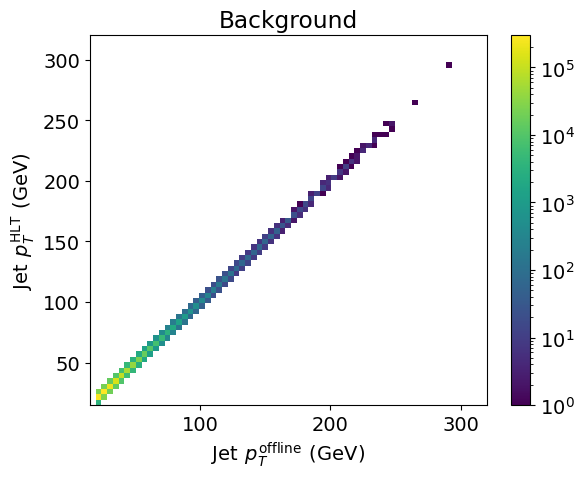

In [ ]:
# Plot 2d histogram to compare offline and HLT pT (background)
import matplotlib
plt.hist2d(ak.flatten(smeared_bkg_data.pt).tolist(), ak.flatten(smeared_bkg_data.pt_smeared).tolist(), bins = (np.linspace(15,320,70), np.linspace(15,320,70)), norm=matplotlib.colors.LogNorm())
plt.xlabel(r'$\mathrm{Jet} \hspace{0.4} p_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel(r'$\mathrm{Jet} \hspace{0.4} p_{T}^{\mathrm{HLT}} \hspace{0.4} \mathrm{(GeV)}$')
plt.colorbar()
plt.title('Background')
plt.show()

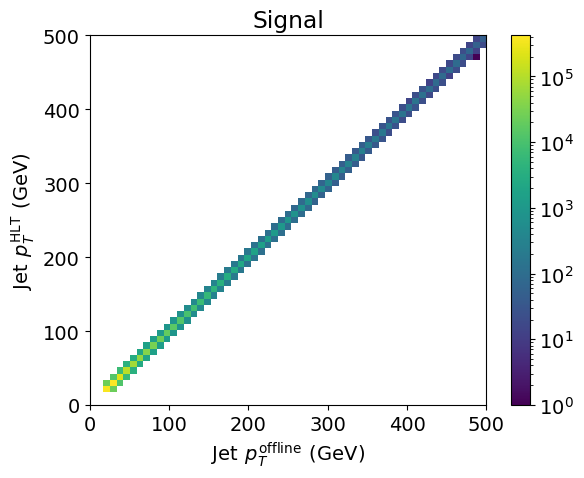

In [ ]:
# Plot 2d histogram to compare offline and HLT pT (signal)
plt.hist2d(ak.flatten(smeared_sig_data.pt).tolist(), ak.flatten(smeared_sig_data.pt_smeared).tolist(), bins = (np.linspace(0,500,60), np.linspace(0,500,60)), norm=matplotlib.colors.LogNorm())
plt.xlabel(r'$\mathrm{Jet} \hspace{0.4} p_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel(r'$\mathrm{Jet} \hspace{0.4} p_{T}^{\mathrm{HLT}} \hspace{0.4} \mathrm{(GeV)}$')
plt.colorbar()
plt.title('Signal')
plt.show()

# V - Prepare data

In [ ]:
# Create array with both offline and HLT jets
data = ak.concatenate([smeared_bkg_data, smeared_sig_data])

In [ ]:
# Retrieve energy (offline) of the fourth leading jet
pt_fourth_leading_jet = []
for event in data:
  if len(event) < 4:
    pt_fourth_leading_jet.append(0)
  else:
    jets_sorted = sorted(event, key=lambda j: j.pt, reverse=True)
    jet_4 = jets_sorted[3]
    pt_4 = jet_4.pt
    pt_fourth_leading_jet.append(pt_4)
pt_fourth_leading_jet = np.array(pt_fourth_leading_jet)

In [ ]:
# If not done before
# Convert to arrays that can be used by EnergyFlow with coordinates (pT,y,phi)
bkg_data_pfn = [
    [[jet['pt'], jet['eta'], jet['phi']] for jet in event]
    for event in smeared_bkg_data
]

sig_data_pfn = [
    [[jet['pt'], jet['eta'], jet['phi']] for jet in event]
    for event in smeared_sig_data
]
data_pfn = bkg_data_pfn + sig_data_pfn

In [ ]:
# Create arrays with the labels
bkg_labels = np.zeros(len(background))
sig_labels = np.ones(len(signal))
y = np.concatenate([bkg_labels, sig_labels])

In [ ]:
# Define some parameters of the EFPs
dmax = 6
measure = 'hadr'
beta = 1
test_frac = 0.2
colors = ['tab:red', 'tab:orange', 'tab:olive', 'tab:green', 'tab:blue', 'tab:purple']

# Define set of graphs
efpset = ef.EFPSet(('d<=',6), measure='hadr',  beta=beta)

In [ ]:
# Calculate all EFPs with d<=dmax
print('Calculating d <= {} EFPs'.format(dmax), end='')
X_HLT = efpset.batch_compute(data_efp)
print('Done')

# Save results
np.save('efps_HLT_dmax6_Mar26.npy', X_HLT)

Calculating d <= 6 EFPsDone


In [ ]:
# Load results with EFPs
X_HLT = np.load('efps_HLT_dmax6_Mar26.npy')

In [ ]:
# Load data with fourth leading pT (offline)
pt4_offline = np.load('pt4_offline.npy')
pt4_bkg_offline = pt4_offline[:len(background)]
pt4_sig_offline = pt4_offline[len(background):]

In [ ]:
# Load data with fourth leading pT (HLT)
pt4_HLT = np.load('pt_fourth_leading_jet.npy')
pt4_bkg_HLT = pt4_HLT[:len(background)]
pt4_sig_HLT = pt4_HLT[len(background):]

In [ ]:
# Load invariant mass arrays
true_mass_bkg = np.load('true_mHH_bkg.npy')
true_mass_sig = np.load('true_mHH_sig.npy')
true_invariant_mass = np.concatenate([true_mass_bkg, true_mass_sig])

# VI - Selection with EFPs (Correlation Plots)

In this section, we apply a cut directly on the EFPs to distinguish signal and background.

In [ ]:
# Define function that, given the index of a EFP on a set, returns
# the corresponding number of vertices and edges
def get_EFP(efpset, i):
  i = int(i)
  graph = efpset.graphs(i)
  n, _, d, v, _, c, p, _ = efpset.specs[i]
  return n, d

In [ ]:
# Example
efpset = ef.EFPSet(('d<=',6), measure='hadr',  beta=beta)
ind = 87

graph = efpset.graphs(ind)
n, _, d, v, _, c, p, _ = efpset.specs[ind]

print("Graph:", graph)
print("Number of vertices, n:", n)
print("Number of edges,    d:", d)
print("Maximum valency,    v:", v)
print("VE complexity,      c:", c)
print("Number of primes,   p:", p)
print()

Graph: [(0, 1), (0, 2), (1, 2), (0, 3), (0, 4)]
Number of vertices, n: 5
Number of edges,    d: 5
Maximum valency,    v: 4
VE complexity,      c: 3
Number of primes,   p: 1



In [ ]:
# Plot roc curve using the histogram of each EFP
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
aucs = []

for i in range(X_HLT.shape[1]):
  EFP_bkg = X_HLT[bkg_idx,i]
  EFP_sig = X_HLT[signal_idx,i]
  scores = np.concatenate([EFP_bkg, EFP_sig])
  roc = roc_curve(y, scores)
  auc = roc_auc_score(y, scores)
  aucs.append(auc)

# Print five max values of auc and select corresponding EFP
max_aucs = np.sort(aucs)[-5:]
print(max_aucs)
max_efps = np.argsort(aucs)[-5:]
print(max_efps)

[0.38965522 0.39165923 0.39831367 0.40809361 0.50030956]
[ 66 111 112 146   0]


In [ ]:
# Print all values of auc
aucs_sort = np.sort(aucs)
print(aucs_sort)

[0.35736197 0.35738783 0.35743235 0.35743235 0.35743235 0.35743235
 0.35743235 0.35743235 0.35745217 0.35763035 0.35763035 0.35783729
 0.35786759 0.3581448  0.35824446 0.35825976 0.35825976 0.35825976
 0.35826423 0.35841505 0.3585014  0.35851664 0.35862764 0.35867576
 0.3586805  0.35890296 0.35891323 0.35912434 0.35912434 0.35912628
 0.35914727 0.3591902  0.35921261 0.35923689 0.35946382 0.35949031
 0.35949554 0.35961571 0.35964796 0.35967233 0.35988887 0.35988887
 0.35996094 0.36001925 0.36005185 0.36005781 0.36007339 0.36007339
 0.36007339 0.36015096 0.36017837 0.360219   0.360221   0.36032399
 0.36040274 0.36047402 0.36058995 0.36062544 0.36064472 0.36065223
 0.36075622 0.36078593 0.36083198 0.36094676 0.36097409 0.36100545
 0.36102889 0.36102889 0.36113996 0.36116167 0.36118628 0.36121698
 0.36121877 0.36123862 0.36124039 0.36125831 0.36126253 0.36143911
 0.36147978 0.36148634 0.36148702 0.36155622 0.36157226 0.36166226
 0.36175935 0.36176334 0.3617739  0.36177557 0.36180997 0.3618

In [ ]:
# Retrieve 5 EFPs with largest AUC (to plot the correlation)
index = [146,112,111,66,133,65,147,62,88,64]
EFPs_bkg = []
columns_bkg = []
EFPs_sig = []
columns_sig = []

for i in index:
  i = int(i)
  EFP_bkg = X_HLT[bkg_idx,i]
  EFP_sig = X_HLT[signal_idx,i]
  n, d = get_EFP(efpset, i)
  EFPs_bkg.append(EFP_bkg)
  EFPs_sig.append(EFP_sig)
  columns_bkg.append("EFP {}: n = {}, d = {}".format(i, n, d))
  columns_sig.append("EFP {}: n = {}, d = {}".format(i, n, d))

# Create pandas DF with transpose EFPs
df_EFPs_bkg = pd.DataFrame(EFPs_bkg)
df_EFPs_bkg = df_EFPs_bkg.transpose()
df_EFPs_bkg.columns = columns_bkg
df_EFPs_sig = pd.DataFrame(EFPs_sig)
df_EFPs_sig = df_EFPs_sig.transpose()
df_EFPs_sig.columns = columns_sig

In [ ]:
# Check result
df_EFPs_bkg

,"EFP 146: n = 7, d = 6","EFP 112: n = 6, d = 6","EFP 111: n = 6, d = 5","EFP 66: n = 5, d = 6","EFP 133: n = 6, d = 6","EFP 65: n = 5, d = 6","EFP 147: n = 7, d = 6","EFP 62: n = 4, d = 6","EFP 88: n = 5, d = 6","EFP 64: n = 5, d = 5"
0,434.818132,553.339285,148.846617,705.034795,354.353544,783.571001,390.337139,269.216134,435.269147,189.672455
1,400.486609,483.990129,132.571976,587.871418,292.927739,632.015673,318.004334,207.616195,355.486900,161.959986
2,450.918092,527.125865,145.605654,617.100842,361.098606,673.053469,369.257202,298.693226,429.786965,171.366260
3,330.159702,404.573740,117.433366,498.593247,262.350847,525.967661,286.940007,185.956711,319.633572,145.369849
4,982.440837,1171.153326,264.929110,1400.950534,676.322861,1523.533758,726.022594,481.788740,812.901039,319.650881
...,...,...,...,...,...,...,...,...,...,...
99995,456.254983,559.556498,153.027749,689.557357,351.225435,741.628453,387.240466,253.281653,425.352859,189.106501
99996,256.319519,308.013361,92.654764,370.591654,208.202978,402.159986,216.564376,166.829827,253.682296,111.892133
99997,992.925024,1251.637892,279.890474,1582.340813,723.723509,1757.994571,791.925610,500.194575,915.398184,355.835668
99998,209.607232,254.943531,82.158100,310.465193,182.533088,336.269826,193.000246,150.406836,219.117418,100.082172


In [ ]:
# Compute correlation matrix (backgorund)
corr_matrix_bkg = df_EFPs_bkg.corr()
corr_matrix_bkg

,"EFP 146: n = 7, d = 6","EFP 112: n = 6, d = 6","EFP 111: n = 6, d = 5","EFP 66: n = 5, d = 6","EFP 133: n = 6, d = 6","EFP 65: n = 5, d = 6","EFP 147: n = 7, d = 6","EFP 62: n = 4, d = 6","EFP 88: n = 5, d = 6","EFP 64: n = 5, d = 5"
"EFP 146: n = 7, d = 6",1.000000,0.998131,0.991530,0.992646,0.980532,0.991629,0.981112,0.942005,0.980157,0.986374
"EFP 112: n = 6, d = 6",0.998131,1.000000,0.993911,0.998180,0.984705,0.997602,0.987970,0.946076,0.985586,0.992399
"EFP 111: n = 6, d = 5",0.991530,0.993911,1.000000,0.992324,0.993520,0.992583,0.993946,0.967634,0.993441,0.998142
"EFP 66: n = 5, d = 6",0.992646,0.998180,0.992324,1.000000,0.984559,0.999790,0.990650,0.945404,0.986680,0.994445
"EFP 133: n = 6, d = 6",0.980532,0.984705,0.993520,0.984559,1.000000,0.986502,0.997962,0.987395,0.999475,0.992605
"EFP 65: n = 5, d = 6",0.991629,0.997602,0.992583,0.999790,0.986502,1.000000,0.992185,0.949507,0.988681,0.994986
"EFP 147: n = 7, d = 6",0.981112,0.987970,0.993946,0.990650,0.997962,0.992185,1.000000,0.979191,0.998434,0.996081
"EFP 62: n = 4, d = 6",0.942005,0.946076,0.967634,0.945404,0.987395,0.949507,0.979191,1.000000,0.984632,0.965174
"EFP 88: n = 5, d = 6",0.980157,0.985586,0.993441,0.986680,0.999475,0.988681,0.998434,0.984632,1.000000,0.993850
"EFP 64: n = 5, d = 5",0.986374,0.992399,0.998142,0.994445,0.992605,0.994986,0.996081,0.965174,0.993850,1.000000


In [ ]:
# Compute correlation matrix (signal)
corr_matrix_sig = df_EFPs_sig.corr()
corr_matrix_sig

,"EFP 146: n = 7, d = 6","EFP 112: n = 6, d = 6","EFP 111: n = 6, d = 5","EFP 66: n = 5, d = 6","EFP 133: n = 6, d = 6","EFP 65: n = 5, d = 6","EFP 147: n = 7, d = 6","EFP 62: n = 4, d = 6","EFP 88: n = 5, d = 6","EFP 64: n = 5, d = 5"
"EFP 146: n = 7, d = 6",1.000000,0.998077,0.988347,0.992508,0.972149,0.990476,0.972590,0.920664,0.968407,0.981369
"EFP 112: n = 6, d = 6",0.998077,1.000000,0.993000,0.998164,0.981072,0.997052,0.983164,0.933910,0.978699,0.989577
"EFP 111: n = 6, d = 5",0.988347,0.993000,1.000000,0.993495,0.992956,0.993849,0.992879,0.961508,0.991165,0.998256
"EFP 66: n = 5, d = 6",0.992508,0.998164,0.993495,1.000000,0.985421,0.999715,0.989334,0.941912,0.984376,0.993608
"EFP 133: n = 6, d = 6",0.972149,0.981072,0.992956,0.985421,1.000000,0.988132,0.998532,0.984868,0.999525,0.994512
"EFP 65: n = 5, d = 6",0.990476,0.997052,0.993849,0.999715,0.988132,1.000000,0.991680,0.947914,0.987475,0.994665
"EFP 147: n = 7, d = 6",0.972590,0.983164,0.992879,0.989334,0.998532,0.991680,1.000000,0.978916,0.998400,0.996419
"EFP 62: n = 4, d = 6",0.920664,0.933910,0.961508,0.941912,0.984868,0.947914,0.978916,1.000000,0.985421,0.965691
"EFP 88: n = 5, d = 6",0.968407,0.978699,0.991165,0.984376,0.999525,0.987475,0.998400,0.985421,1.000000,0.994013
"EFP 64: n = 5, d = 5",0.981369,0.989577,0.998256,0.993608,0.994512,0.994665,0.996419,0.965691,0.994013,1.000000


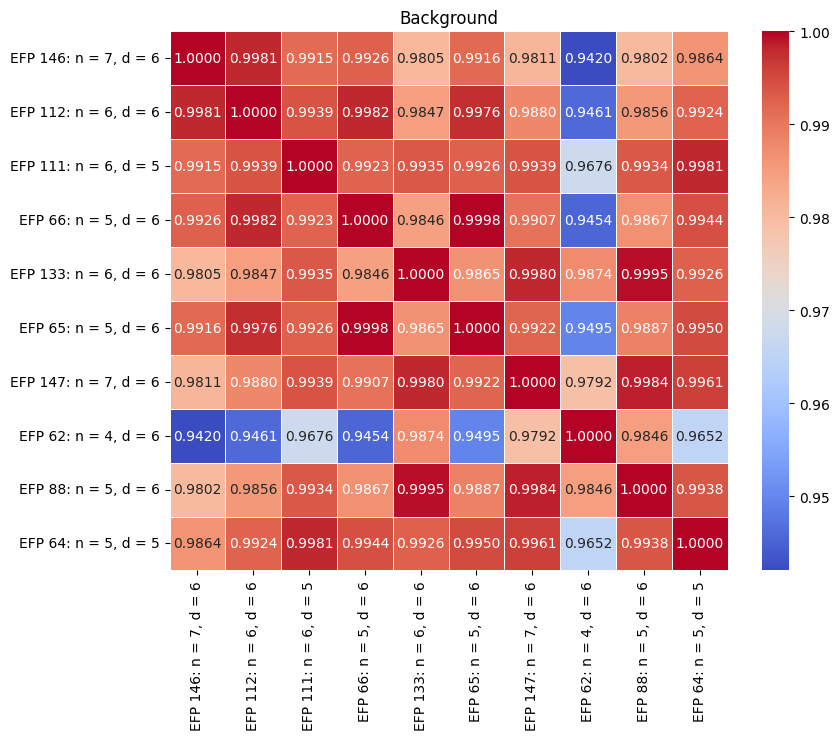

In [ ]:
# Plot correlation matrix (background)
import seaborn as sns
plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix_bkg, annot=True, cmap="coolwarm", fmt=".4f", linewidths=0.5)
plt.title("Background")
plt.show()

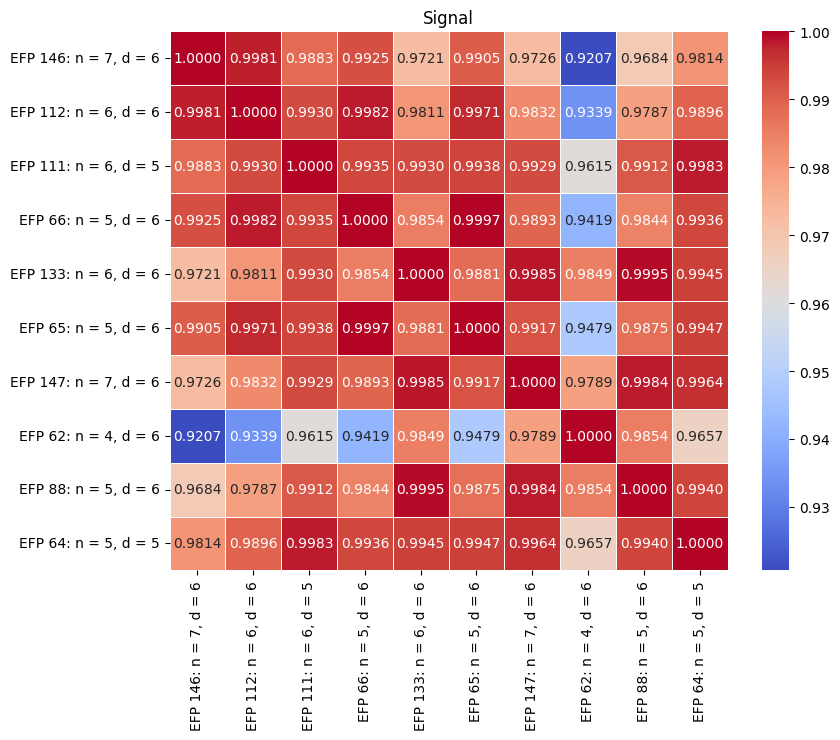

In [ ]:
# Plot correlation matrix (signal)
plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix_sig, annot=True, cmap="coolwarm", fmt=".4f", linewidths=0.5)
plt.title("Signal")
plt.show()

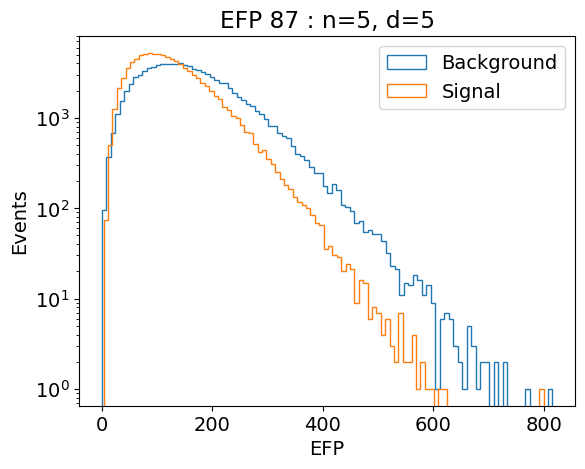

In [ ]:
# Plot histogram of one EFP (example)
i = 87
EFP_bkg = X_HLT[bkg_idx,i]
EFP_sig = X_HLT[signal_idx,i]
n, d = get_EFP(efpset, i)
plt.hist(EFP_bkg, bins=100, histtype='step', label='Background')
plt.hist(EFP_sig, bins=100, histtype='step',label='Signal')
plt.title('EFP {} : n={}, d={}'.format(i, n, d))
plt.xlabel('EFP')
plt.ylabel('Events')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

# VII - Baseline (pT cut)

In this section, we apply a cut on the fourth-leading jet pT (HLT) to distinguish signal and background - this simulates a standard multijet trigger with a transverse momentum cut.

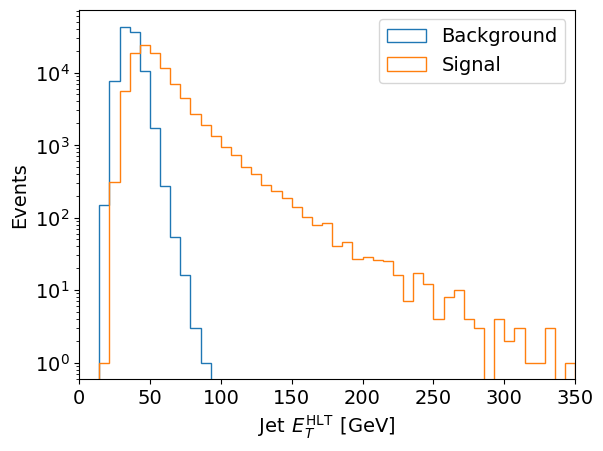

In [ ]:
# Plot distribution of the HLT energy of the fourth leading jet
# for signal and background
plt.hist(pt4_bkg_HLT, bins=np.linspace(0.01,350,50), histtype='step', label='Background')
plt.hist(pt4_sig_HLT, bins=np.linspace(0.01,350,50), histtype='step',label='Signal')
plt.xlim(0, 350)
plt.yscale('log')
plt.xlabel(r'$\mathrm{Jet} \hspace{0.4} E_{T}^{\mathrm{HLT}} \hspace{0.4} \mathrm{[GeV]}$')
plt.ylabel('Events')
plt.legend()
plt.show()

In [ ]:
# Select energy threshold for 5% background acceptance

# Define histogram for bkg ET4(HLT)
bins = np.linspace(0.01,320,30)
counts, edges = np.histogram(pt4_bkg_HLT, bins = bins)
# Calculate histogram integral
total_integral = np.sum(counts)
# Calculate the bkg efficiency for each threshold
thresholds = []
background_efficiency = []
bkg_counts = 0
for i in range(len(counts)):
  bkg_counts += counts[i]
  if total_integral != 0:
    bkg_acceptance = bkg_counts/total_integral
    background_efficiency.append(bkg_acceptance)
    cut = edges[i+1]
    thresholds.append(cut)
    if bkg_acceptance >= 0.95:
      threshold = cut
      break
print(f'The 5% acceptance threshold is: {threshold:.4f}')

The 5% acceptance threshold is: 55.1807


### Energy of the fourth-leading jet

In [ ]:
# Retrieve energy of the fourth leading jet  for the selected signal and for all signal events
tot_sig_energies = []
sel_sig_energies = []

for i in range(len(pt4_sig_HLT)):
  if pt4_sig_HLT[i] != 0:
    tot_sig_energies.append(pt4_sig_offline[i])
    if pt4_sig_HLT[i] >= threshold:
      sel_sig_energies.append(pt4_sig_offline[i])

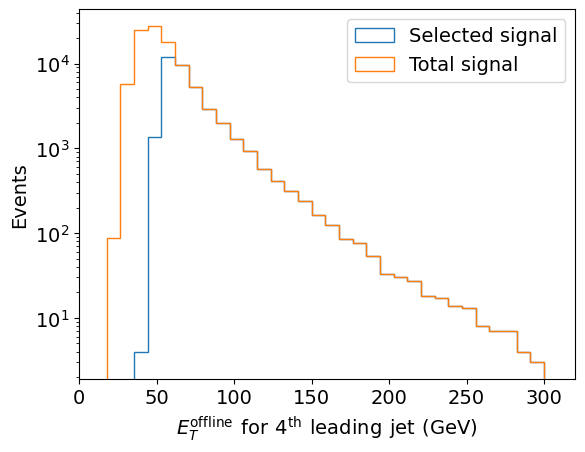

In [ ]:
# Plot distribution of the energy of the fourth leading jet for the selected signal and for all signal events
plt.hist(sel_sig_energies, bins=np.linspace(0.1,300,35), histtype='step', label='Selected signal')
plt.hist(tot_sig_energies, bins=np.linspace(0.1,300,35), histtype='step',label='Total signal')
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,320)
plt.legend()
plt.show()

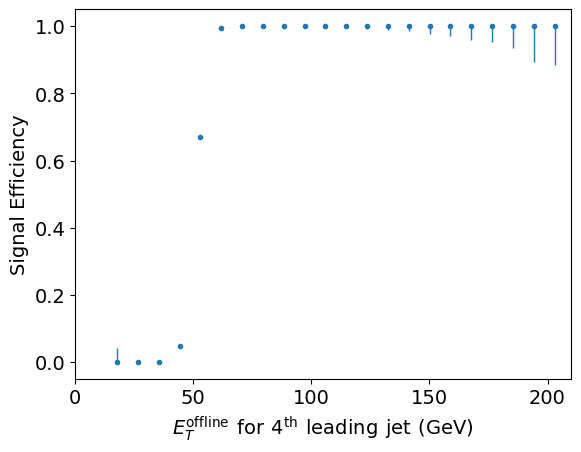

In [ ]:
# Define histograms of the energies
bins=np.linspace(0.1,300,35)
selected_counts, edges = np.histogram(sel_sig_energies, bins=bins)
signal_counts, edges1 = np.histogram(tot_sig_energies, bins=bins)
# Define arrays to store the signal efficiency and jet energy
signal_efficiency_pt = []
energy_pt = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency_pt.append(sel_sig_i/sig_i)
    energy_pt.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low_pt, ci_upp_pt = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low_pt = signal_efficiency_pt - ci_low_pt
err_upp_pt = ci_upp_pt - signal_efficiency_pt
# Plot signal efficiency as a function of the energy
plt.errorbar(energy_pt, signal_efficiency_pt, yerr=[err_low_pt, err_upp_pt], fmt='.', elinewidth=1)
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Signal Efficiency')
plt.xlim(0,210)
plt.show()

In [ ]:
# Save results to plot later
np.savez('baseline_pt4_HLT.npz', energy=energy_pt, signal_eff=signal_efficiency_pt, err_low=err_low_pt, err_upp=err_upp_pt)

## Invariant mass

In [ ]:
# Retrieve invariant mass of the 4b system for the selected signal and for all signal events
signal_mass = []
selected_mass = []

for i in range(len(pt4_sig_HLT)):
  if pt4_sig_HLT[i] != 0:
    signal_mass.append(true_mass_sig[i])
    if pt4_sig_HLT[i] >= threshold:
      selected_mass.append(true_mass_sig[i])

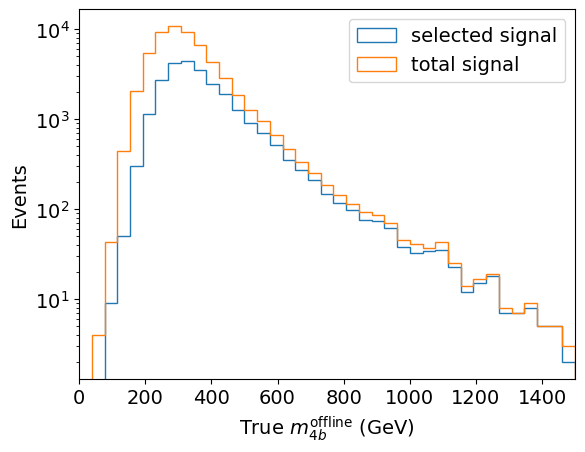

In [ ]:
# Plot distribution of the invariant mass for the selected signal and for all signal events
plt.hist(selected_mass, bins=np.linspace(0.1,1500,40), histtype='step', label='selected signal')
plt.hist(signal_mass, bins=np.linspace(0.1,1500,40), histtype='step',label='total signal')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,1500)
plt.legend()
plt.show()

In [ ]:
# Define histograms of the energies
bins=np.linspace(0.1,1500,40)
selected_counts, edges = np.histogram(selected_mass, bins=bins)
signal_counts, edges1 = np.histogram(signal_mass, bins=bins)
# Define arrays to store the signal efficiency and invariant mass
signal_efficiency = []
mass = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    mass.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency

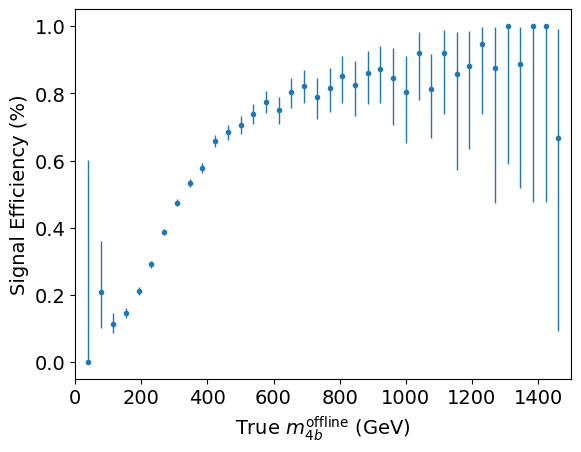

In [ ]:
# Plot signal efficiency as a function of the energy
plt.errorbar(mass, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1)
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Signal Efficiency (%)')
plt.xlim(0,1500)
plt.show()

In [ ]:
# Save results to plot later
np.savez('baseline_mass_HLT.npz', energy=mass, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

# VIII - Define functions

In [ ]:
"""
plot_scores: plots the output scores distribution for signal and background.
The function takes as input two arrays, corresponding to the background and
signal scores and plots them in a histogram.
"""
def plot_scores(preds_bkg, preds_sig):
  plt.hist(preds_bkg, bins=np.linspace(0,1,100), histtype='step', label='background')
  plt.hist(preds_sig, bins=np.linspace(0,1,100), histtype='step',label='signal')
  plt.xlabel('Classifier Output')
  plt.ylabel('Events')
  plt.legend()
  plt.show()

In [ ]:
"""
get_threshold: calculates the 5% background acceptance threshold.
The function takes as input the background scores and returns the threshold
that gives a background acceptance of 0.05.
"""
def get_threshold(preds_bkg):
  # Define histogram for bkg scores
  bins = np.linspace(0,1,500)
  counts, edges = np.histogram(preds_bkg, bins = bins)
  # Calculate histogram integral
  total_integral = np.sum(counts)
  # Calculate the bkg efficiency for each threshold
  thresholds = []
  background_efficiency = []
  bkg_counts = 0
  for i in range(len(counts)):
    bkg_counts += counts[i]
    if total_integral != 0:
      bkg_acceptance = bkg_counts/total_integral
      background_efficiency.append(bkg_acceptance)
      cut = edges[i+1]
      thresholds.append(cut)
      if bkg_acceptance >= 0.95:
        return(cut)

In [ ]:
"""
signal_energies: retrieves the energy of the fourth leading jet for all signal events.
The function takes as input the test set and returns an array with the energy of the
fourth leading jet for the signal events.
"""
def signal_energies(X_test, y_test, pt4_test):
  signal_energies = []
  for i in range(len(X_test)):
    if y_test[i] == 1:
      if pt4_test[i] != 0:
        signal_energies.append(pt4_test[i])
  return signal_energies

"""
selected_energies: retrieves the energy of the fourth leading jet for all selected signal events.
The function takes as input the array with the predictions, the threshold and
labels and energy of the test set and returns an array with the energy of the
fourth leading jet for the selected signal events.
"""
def selected_energies(preds, y_test, pt4_test, cut):
  selected_energies = []
  for i in range(len(preds)):
    if preds[i] >= cut and y_test[i] == 1:
      selected_energies.append(pt4_test[i])
  return selected_energies

# IX - Linear Classifier

In this section, we apply a linear classifier (Linear Discriminant Analysis) to distinguish signal and background using supervised learning.

## 1 - Test different dmax


EFPs d <= 1 AUC: 0.6420529026480575


EFPs d <= 2 AUC: 0.6447292033694147


EFPs d <= 3 AUC: 0.805290089833061


EFPs d <= 4 AUC: 0.8727793912177987


EFPs d <= 5 AUC: 0.9067522761566758


EFPs d <= 6 AUC: 0.9266028037999656



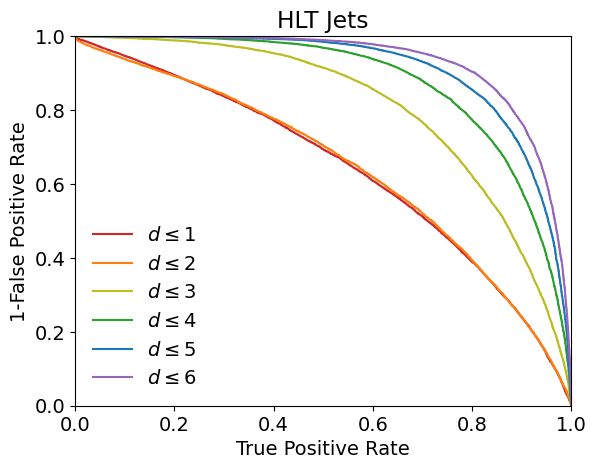

In [ ]:
# Train models with different numbers of EFPs as input
dmax = 6
rocs = []
aucs = []
for d in range(1, dmax+1):

    # build architecture
    model =LinearDiscriminantAnalysis(tol=1e-12)

    # select EFPs with degree <= d
    X_d = X_HLT[:,efpset.sel(('d<=', d))]

    # Split into training and test sets
    (X_train, X_test, y_train, y_test) = train_test_split(X_d, y, test_size=test_frac)

    # Standardize data
    scaler = StandardScaler()
    X_train_nor = scaler.fit_transform(X_train)
    X_test_nor = scaler.transform(X_test)

    # train model
    model.fit(X_train_nor, y_train)

    # get predictions on test data
    preds = model.predict_proba(X_test_nor)

    # get ROC curve if we have sklearn
    if roc_curve:
        rocs.append(roc_curve(y_test, preds[:,1]))

        # get area under the ROC curve
        auc = roc_auc_score(y_test, preds[:,1])
        aucs.append(auc)
        print()
        print('EFPs d <= {} AUC:'.format(d), auc)
        print()

# iterate over the ROC curves and plot them
for i,d in enumerate(range(1, dmax+1)):
    plt.plot(rocs[i][1], 1-rocs[i][0], '-', color=colors[i],
                                            label=r'$d \leq${}'.format(d))

# axes labels
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.title('HLT Jets')
# axes limits
plt.xlim(0, 1)
plt.ylim(0, 1)

# make legend and show plot
plt.legend(loc='lower left', frameon=False)
plt.show()

## 2 - Turn-on Curve

In this section, the inputs of the classifier are all the EFPs with d<=6 (205 EFPs per event).

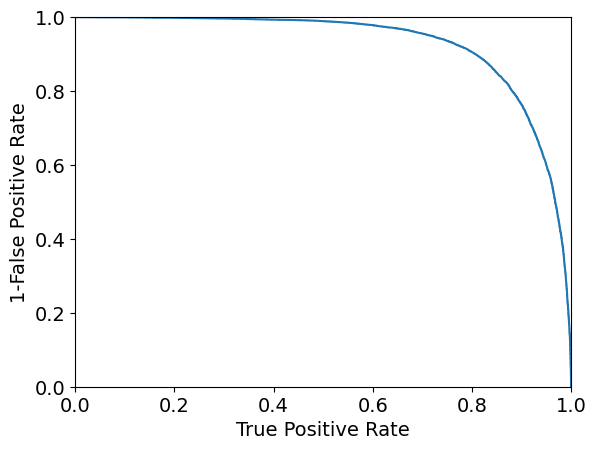


AUC: 0.9265983449999999



In [ ]:
# Define model
linear_model = LinearDiscriminantAnalysis(tol=1e-12)

# Split into training and test sets
test_frac = 0.2
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]

X_sig_train, X_sig_test, pt4_sig_train, pt4_sig_test, mass_sig_train, mass_sig_test, y_sig_train, y_sig_test = train_test_split(
    X_HLT[signal_idx], pt4_offline[signal_idx], true_invariant_mass[signal_idx], y[signal_idx], test_size=test_frac, random_state=42
)

X_bkg_train, X_bkg_test, pt4_bkg_train, pt4_bkg_test, mass_bkg_train, mass_bkg_test, y_bkg_train, y_bkg_test = train_test_split(
    X_HLT[bkg_idx], pt4_offline[bkg_idx], true_invariant_mass[signal_idx], y[bkg_idx], test_size=test_frac, random_state=42
)

X_train = np.concatenate([X_bkg_train, X_sig_train])
y_train = np.concatenate([y_bkg_train, y_sig_train])

X_test  = np.concatenate([X_bkg_test,  X_sig_test])
y_test  = np.concatenate([y_bkg_test,  y_sig_test])
pt4_test = np.concatenate([pt4_bkg_test, pt4_sig_test])
mass_test = np.concatenate([mass_bkg_test, mass_sig_test])

# Standardize data
scaler = StandardScaler()
X_train_nor = scaler.fit_transform(X_train)
X_test_nor = scaler.transform(X_test)

# Train model
linear_model.fit(X_train_nor, y_train)

# Get predictions on the test set
preds = linear_model.predict_proba(X_test_nor)

# Plot ROC curve
roc = roc_curve(y_test, preds[:,1])
plt.plot(roc[1], 1-roc[0], '-')
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# Print AUC
auc = roc_auc_score(y_test, preds[:,1])
print()
print('AUC:'.format(auc), auc)
print()

In [ ]:
# Divide test set into signal and background events and retrieve corresponding scores
preds_bkg = preds[y_test == 0][:,1]
preds_sig = preds[y_test == 1][:,1]

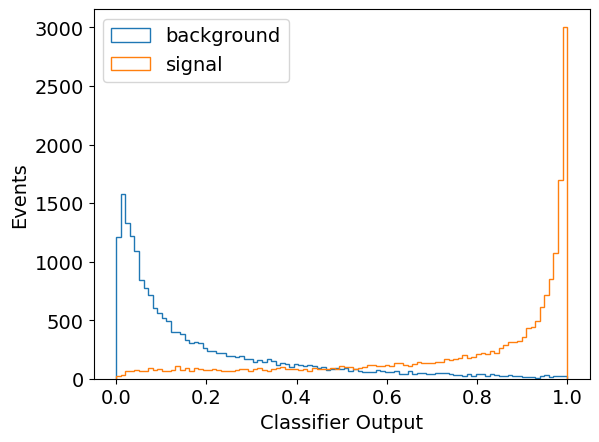

In [ ]:
# Plot classifier output
plot_scores(preds_bkg, preds_sig)

In [ ]:
# Compute the 5% background aceptance threshold
cut = get_threshold(preds_bkg)
print(f'The 5% acceptance threshold is: {cut:.4f}')

The 5% acceptance threshold is: 0.6693


### Energy of the fourth-leading jet

In [ ]:
# Retrieve pT of the fourth leading jet for all signal events
signal_energies = []
selected_energies = []
for i in range(len(X_test)):
  if y_test[i] == 1:
    if pt4_test[i] != 0:
      signal_energies.append(pt4_test[i])
      if preds[i][1] >= cut:
        selected_energies.append(pt4_test[i])

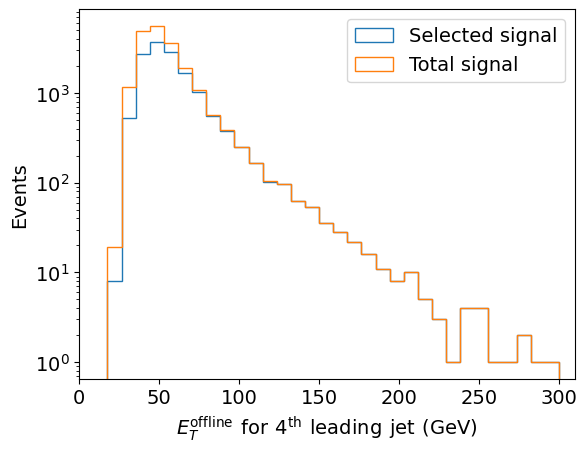

In [ ]:
# Plot distribution of the energy of the fourth leading jet for the selected signal and for all signal events
plt.hist(selected_energies, bins=np.linspace(0.1,300,35), histtype='step', label='Selected signal')
plt.hist(signal_energies, bins=np.linspace(0.1,300,35), histtype='step',label='Total signal')
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,310)
plt.legend()
plt.show()

In [ ]:
bins=np.linspace(0.1,300,35)
selected_counts_lda, edges = np.histogram(selected_energies, bins=bins)
signal_counts, edges1 = np.histogram(signal_energies, bins=bins)
# Define arrays to store the signal efficiency and jet energy
signal_efficiency_lda = []
energy_lda = []
sel_sig_counts_lda = []
sig_counts_lda = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts_lda)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts_lda[i]
  if sig_i != 0:
    sig_counts_lda.append(sig_i)
    sel_sig_counts_lda.append(sel_sig_i)
    signal_efficiency_lda.append(sel_sig_i/sig_i)
    energy_lda.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low_lda, ci_upp_lda = proportion_confint(sel_sig_counts_lda, sig_counts_lda, alpha=0.05, method='beta')
# Compute error bars
err_low_lda = signal_efficiency_lda - ci_low_lda
err_upp_lda = ci_upp_lda - signal_efficiency_lda

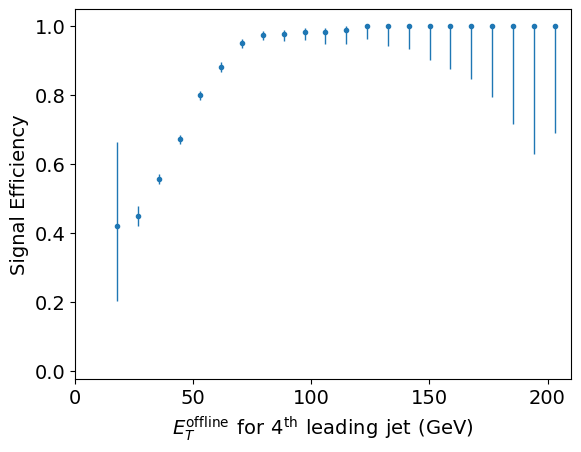

In [ ]:
# Plot signal efficiency as a function of the energy
plt.errorbar(energy_lda, signal_efficiency_lda, yerr=[err_low_lda, err_upp_lda], fmt='.', elinewidth=1)
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Signal Efficiency')
plt.xlim(0,210)

plt.show()

In [ ]:
# Save results to plot later
np.savez('HLT_jets_pt4.npz', energy=energy_lda, signal_eff=signal_efficiency_lda, err_low=err_low_lda, err_upp=err_upp_lda)

### Invariant mass of the bbbb system

In [ ]:
# Retrieve pT of the fourth leading jet for all signal events
signal_mass = []
selected_mass = []
for i in range(len(X_test)):
  if y_test[i] == 1:
    if mass_test[i] != 0:
      signal_mass.append(mass_test[i])
      if preds[i][1] >= cut:
        selected_mass.append(mass_test[i])

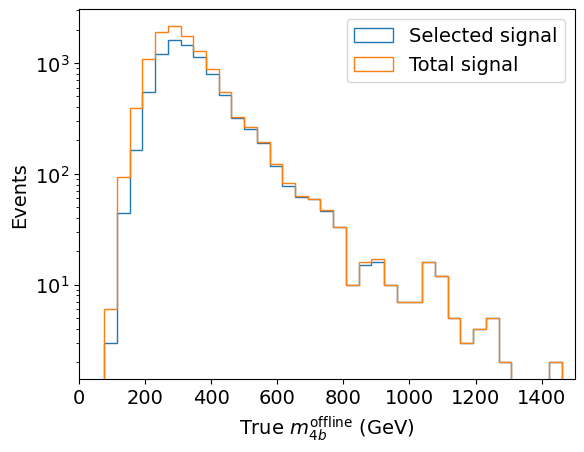

In [ ]:
# Plot distribution of the invariant mass for the selected signal and for all signal events
plt.hist(selected_mass, bins=np.linspace(0.1,1500,40), histtype='step', label='Selected signal')
plt.hist(signal_mass, bins=np.linspace(0.1,1500,40), histtype='step',label='Total signal')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,1500)
plt.legend()
plt.show()

In [ ]:
# Define histograms of the energies
bins=np.linspace(0.1,1500,40)
selected_counts, edges = np.histogram(selected_mass, bins=bins)
signal_counts, edges1 = np.histogram(signal_mass, bins=bins)
# Define arrays to store the signal efficiency and invariant mass
signal_efficiency = []
mass = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    mass.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency

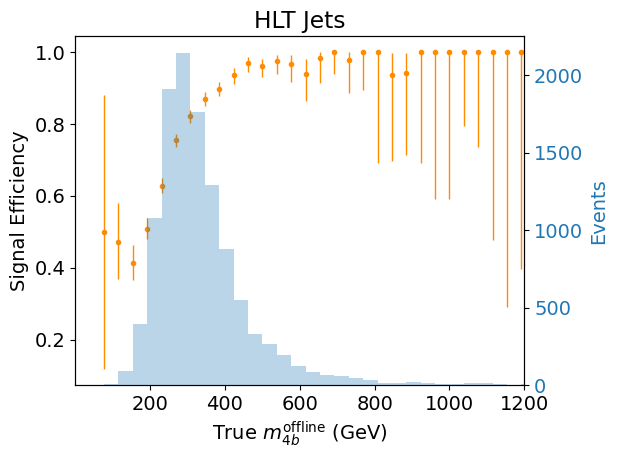

In [ ]:
# Test adding invariant mass distribution in the background
fig, ax1 = plt.subplots()

ax1.set_xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(mass, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1, color='darkorange')

ax2 = ax1.twinx()
ax2.set_ylabel('Events', color= colors[4])
ax2.hist(signal_mass, bins=np.linspace(0.1,1500,40), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.set_xlim(0.1,1200)
ax1.set_title('HLT Jets')
fig.tight_layout()
plt.show()

In [ ]:
# Save results to plot later
np.savez('HLT_jets_mass.npz', energy=mass, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

### SHAP Analysis

In [ ]:
# Create SHAP explainer
explainer = shap.LinearExplainer(linear_model, X_train_nor, feature_pertubation="correlation")

# Compute SHAP and base values
shap_values = explainer.shap_values(X_test_nor)
base_value = explainer.expected_value

# Compute mean of the absolute sort values and use it to order features
importance = np.abs(shap_values).mean(axis=0)
feature_order = np.argsort(importance)[::-1]

# Reorder SHAP values
shap_sorted = shap_values[:, feature_order]

# Retrain classifierwhile adding more features (by order of importance)
n_features = shap_sorted.shape[1]
auc_scores = []

for k in range(1, n_features + 1):
    selected = feature_order[:k]

    X_train_k = X_train[:,selected]
    X_test_k  = X_test[:,selected]

    model_k = LinearDiscriminantAnalysis()
    model_k.fit(X_train_k, y_train)

    pred_k = model_k.decision_function(X_test_k)
    auc = roc_auc_score(y_test, pred_k)

    auc_scores.append(auc)

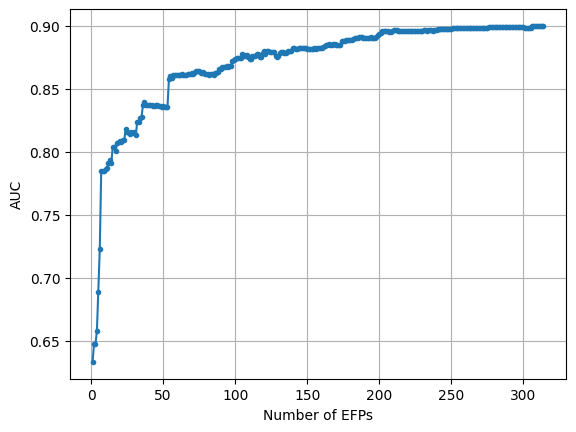

In [ ]:
# Plot AUC as a function of number of features used in training
plt.plot(range(1, n_features + 1), auc_scores, marker='.')
plt.xlabel("Number of EFPs")
plt.ylabel("AUC")
plt.grid()
plt.show()

In [ ]:
feature_order

array([277, 300, 250, 286, 261, 292, 156, 284, 239, 242, 255, 295, 290,
       135, 149, 262, 155, 245, 291, 302, 251, 306, 154, 144, 205, 278,
       153, 281, 276, 151, 231, 258, 294, 249, 246, 248, 220, 256, 141,
       253, 240, 283, 202, 139, 198, 257, 285, 288, 234, 142, 305, 137,
       203, 224, 134, 145, 197, 124, 264, 121, 206, 116, 119, 122, 299,
       214, 102,  96, 236, 211, 143,  68, 217, 194, 204, 128, 293,  76,
       270, 218, 252,  92, 238, 127, 267, 223,  93, 152, 100,  74,  86,
       289, 309, 279, 213, 123, 101, 118, 106, 225, 260, 282, 241, 275,
       212,  80,  52, 117, 179, 125, 180,  69, 148, 287, 195, 247, 113,
        79,  81,  90, 201,  73, 131,  67, 132, 210, 129, 170, 244, 222,
        75, 233, 193, 297, 199, 269,  91, 243, 147, 108, 259, 150, 196,
       208, 209, 311, 312, 301, 237, 172,  83, 310, 191,  64,  43,  85,
        39, 178, 133, 235,  88,  42, 173, 184, 188,  33, 112, 207, 104,
       103, 265,  97,  45,  60,  66, 229,  36, 200, 215, 271,  2

In [ ]:
# retrieve 10 EFPs with larger feature importance
index = feature_order[:10]
EFPs = []
is_prime= []
columns = []
for i in index:
  i = int(i)
  EFP = X_HLT[:,i]
  n, d = get_EFP(efpset, i)
  p = is_EFP_prime(efpset, i)
  EFPs.append(EFP)
  columns.append("EFP {}: n = {}, d = {}, p={}".format(i, n, d,p))
# create pandas DF with transpose EFPs
df_EFPs = pd.DataFrame(EFPs)
df_EFPs = df_EFPs.transpose()
df_EFPs.columns = columns

In [ ]:
df_EFPs

,"EFP 131: n = 6, d = 6, p=1","EFP 153: n = 7, d = 6, p=1","EFP 91: n = 5, d = 5, p=1","EFP 122: n = 6, d = 6, p=1","EFP 75: n = 5, d = 6, p=1","EFP 120: n = 6, d = 5, p=1","EFP 69: n = 5, d = 5, p=1","EFP 117: n = 6, d = 5, p=1","EFP 151: n = 7, d = 6, p=1","EFP 68: n = 5, d = 5, p=1"
0,441.552994,344.082169,121.399660,450.036864,651.271548,129.976093,179.376811,133.215007,351.609534,174.942020
1,317.285020,247.642655,95.981103,325.554439,495.522088,98.504875,141.448185,103.210715,256.121718,137.089576
2,353.333890,293.751902,116.705069,365.266631,531.935472,113.999761,154.147710,118.870789,304.801933,148.628694
3,320.850278,250.870586,93.847039,324.828417,450.847870,99.691143,134.411800,101.949155,254.761277,132.826111
4,672.703303,537.741616,186.510868,693.549894,1103.467782,188.455945,270.738271,197.164460,557.703771,260.788017
...,...,...,...,...,...,...,...,...,...,...
199995,298.369353,240.896023,96.695078,307.189237,459.082113,96.508861,134.487178,100.652119,249.391546,129.506788
199996,295.423957,236.418369,97.823832,308.189604,519.769160,95.055705,142.087830,101.418189,248.856773,135.790897
199997,649.676101,526.953778,185.291235,668.971714,993.979688,185.359423,256.820476,193.084412,545.465253,246.912379
199998,390.102824,316.057819,116.539583,395.516494,527.710943,121.080481,156.870097,123.215567,320.911833,154.430370


In [ ]:
# Select EFPs corresponding to the most important features in X_HLT
# X_HLT_cut can then be used to repeat the analysis in section IX.2
X_HLT_cut = []
index = feature_order[:100]
for i in range(len(X_HLT)):
  EFP = []
  for e in index:
    EFP.append(X_HLT[i][e])
  X_HLT_cut.append(EFP)
X_HLT_cut = np.array(X_HLT_cut)

# X - PFN

In this section, we apply Particle Flow Networks (PFN) to distinguish signal and background using supervised learning.

In [ ]:
# Convert labels to categorical
# bkg (1,0) and sig (0,1)
y_categorical = to_categorical(y, num_classes=2)

In [ ]:
# Apply padding with all-zero particles such that all events have the same
# number of jets
X_padded = pad_sequences(data_pfn, padding='post', dtype='float32', value=0.0)

test_frac = 0.2
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]

X_sig_train, X_sig_test,  pt4_sig_train, pt4_sig_test, mass_sig_train, mass_sig_test, y_sig_train, y_sig_test = train_test_split(
    X_padded[signal_idx], pt4_offline[signal_idx], true_invariant_mass[signal_idx], y_categorical[signal_idx], test_size=0.2, random_state=42
)

X_bkg_train, X_bkg_test, pt4_bkg_train, pt4_bkg_test, mass_bkg_train, mass_bkg_test, y_bkg_train, y_bkg_test = train_test_split(
    X_padded[bkg_idx], pt4_offline[bkg_idx], true_invariant_mass[bkg_idx], y_categorical[bkg_idx], test_size=0.2, random_state=42
)

X_train = np.concatenate([X_sig_train, X_bkg_train])
y_train = np.concatenate([y_sig_train, y_bkg_train])

X_test  = np.concatenate([X_sig_test,  X_bkg_test])
y_test  = np.concatenate([y_sig_test,  y_bkg_test])
pt4_test = np.concatenate([pt4_sig_test, pt4_bkg_test])
mass_test = np.concatenate([mass_sig_test, mass_bkg_test])

In [ ]:
# Define masking layer to ensure all zero jets are not considered
masking_layer = tf.keras.layers.Masking(mask_value=0.0)
# Apply masking
masked_X_train = masking_layer(X_train)
masked_X_test = masking_layer(X_test)

# Define and apply normalization layer
scaler_layer = tf.keras.layers.Normalization(axis=-1)
scaler_layer.adapt(masked_X_train)

X_train_norm = scaler_layer(masked_X_train)
X_train_norm = np.array(X_train_norm)

X_test_norm = scaler_layer(masked_X_test)
X_test_norm = np.array(X_test_norm)

In [ ]:
# PFN network architecture parameters
Phi_sizes, F_sizes = (100, 100, 128), (100, 100, 100)
# Phi_sizes, F_sizes = (100, 100, 256), (100, 100, 100)

# PFN network training parameters
num_epoch = 15
batch_size = 500

In [ ]:
# build architecture
pfn = PFN(input_dim=X_train.shape[-1], Phi_sizes=Phi_sizes, F_sizes=F_sizes)

# train model
pfn.fit(X_train_norm, y_train,
        epochs=num_epoch,
        batch_size=batch_size,
        verbose=1)

# get predictions on test data
preds = pfn.predict(X_test_norm)

# get ROC curve
pfn_fp, pfn_tp, threshs = roc_curve(y_test[:,1], preds[:,1])

# get area under the ROC curve
auc = roc_auc_score(y_test[:,1], preds[:,1])
print()
print('PFN AUC:', auc)
print()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, None, 3)]            0         []                            
                                                                                                  
 tdist_0 (TimeDistributed)   (None, None, 100)            400       ['input[0][0]']               
                                                                                                  
 activation (Activation)     (None, None, 100)            0         ['tdist_0[0][0]']             
                                                                                                  
 tdist_1 (TimeDistributed)   (None, None, 100)            10100     ['activation[0][0]']          
                                                                                              

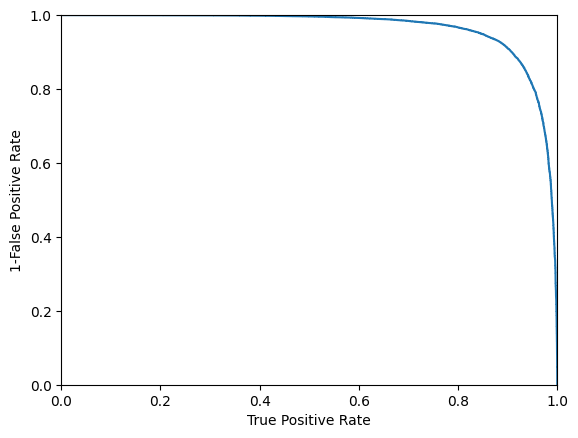


AUC: 0.96471300125



In [ ]:
# Plot ROC curve
pfn_fp, pfn_tp, threshs = roc_curve(y_test[:,1], preds[:,1])
plt.plot(pfn_tp, 1-pfn_fp, '-')
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# Print AUC
auc = roc_auc_score(y_test[:,1], preds[:,1])
print()
print('AUC:'.format(auc), auc)
print()

In [ ]:
# Divide test set into signal and background events and retrieve corresponding scores
preds_bkg = []
preds_sig = []
for i in range(len(y_test)):
  if y_test[i][1] == 0:
    preds_bkg.append(preds[i][1])
  if y_test[i][1] == 1:
    preds_sig.append(preds[i][1])

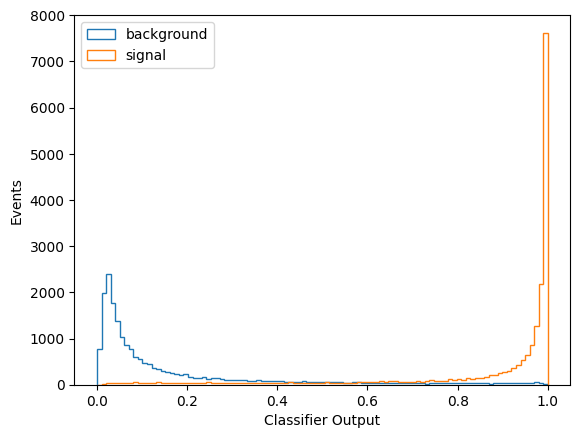

In [ ]:
# Plot classifier output
plot_scores(preds_bkg, preds_sig)

In [ ]:
# Compute the 5% background aceptance threshold
cut = get_threshold(preds_bkg)
print(f'The 5% acceptance threshold is: {cut:.4f}')

The 5% acceptance threshold is: 0.7114


## Energy of the fourth-leading jet

In [ ]:
# Retrieve pT of the fourth leading jet for all signal events
signal_energies = []
for i in range(len(X_test_norm)):
  if y_test[i][1] == 1:
    signal_energies.append(pt4_test[i])

# Retrieve pT of the fourth leading jet for the selected signal events
selected_energies = []
for i in range(len(preds)):
  if preds[i][1] >= cut and y_test[i][1] == 1:
    selected_energies.append(pt4_test[i])

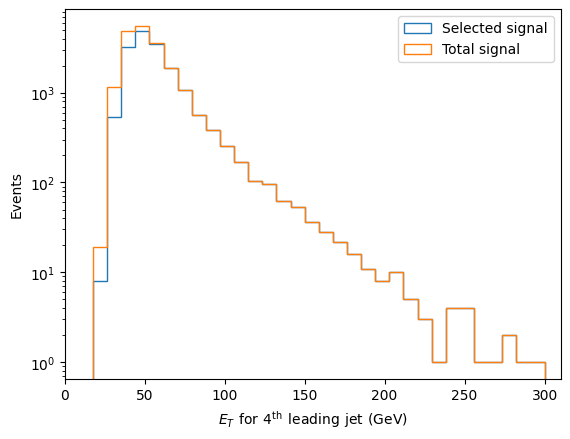

In [ ]:
# Plot distribution of the energy of the fourth leading jet for the selected signal and for all signal events
plt.hist(selected_energies, bins=np.linspace(0.1,300,35), histtype='step', label='Selected signal')
plt.hist(signal_energies, bins=np.linspace(0.1,300,35), histtype='step',label='Total signal')
plt.xlabel(r'$E_{T} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,310)
plt.legend()
plt.show()

In [ ]:
bins=np.linspace(0.1,300,35)
selected_counts, edges = np.histogram(selected_energies, bins=bins)
signal_counts, edges1 = np.histogram(signal_energies, bins=bins)
# Define arrays to store the signal efficiency and jet energy
signal_efficiency = []
energy = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    energy.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency

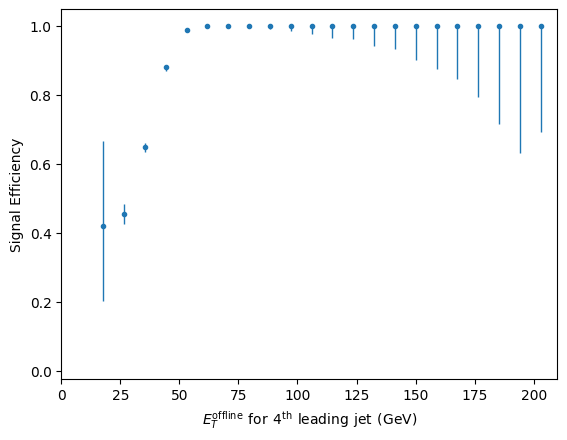

In [ ]:
# Plot signal efficiency as a function of the energy
plt.errorbar(energy, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1)
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Signal Efficiency')
plt.xlim(0,210)

plt.show()

In [ ]:
np.savez('HLT_jets_pfn_pt4.npz', energy=energy, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

## Invariant mass of the bbbb system

In [ ]:
# Retrieve pT of the fourth leading jet for all signal events
signal_mass = []
selected_mass = []
for i in range(len(X_test)):
  if y_test[i][1] == 1:
    if mass_test[i] != 0:
      signal_mass.append(mass_test[i])
      if preds[i][1] >= cut and y_test[i][1] == 1:
        selected_mass.append(mass_test[i])

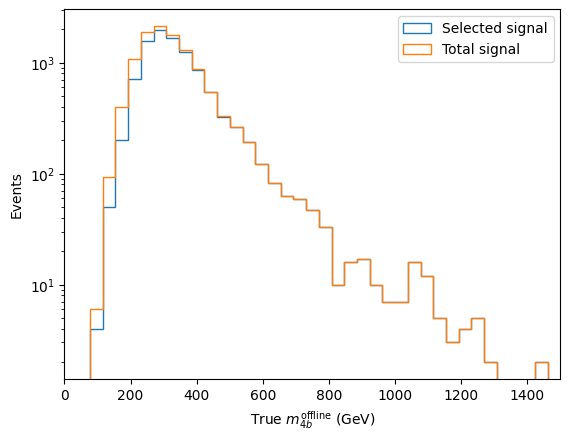

In [ ]:
# Plot distribution of the invariant mass for the selected signal and for all signal events
plt.hist(selected_mass, bins=np.linspace(0.1,1500,40), histtype='step', label='Selected signal')
plt.hist(signal_mass, bins=np.linspace(0.1,1500,40), histtype='step',label='Total signal')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,1500)
plt.legend()
plt.show()

In [ ]:
# Define histograms of the energies
bins=np.linspace(0.1,1500,40)
selected_counts, edges = np.histogram(selected_mass, bins=bins)
signal_counts, edges1 = np.histogram(signal_mass, bins=bins)
# Define arrays to store the signal efficiency and invariant mass
signal_efficiency = []
mass = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    mass.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency

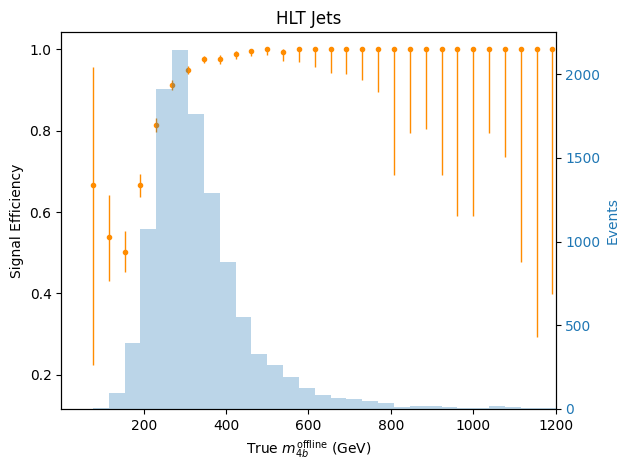

In [ ]:
fig, ax1 = plt.subplots()

ax1.set_xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')

ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(mass, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1, color='darkorange')
#ax1.tick_params(axis='y', labelcolor='darkorange')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('Events', color= colors[4])  # we already handled the x-label with ax1
ax2.hist(signal_mass, bins=np.linspace(0.1,1500,40), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.set_xlim(0.1,1200)
ax1.set_title('HLT Jets')
fig.tight_layout()
plt.show()

In [ ]:
np.savez('HLT_jets_pfn_mass.npz', energy=mass, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

# XI - Turn-on comparison

In this section, we compare the turn-on curves for the different selection methods.

In [ ]:
HLT_jets_lda_pt4 = np.load('HLT_jets_lda_pt4.npz')
HLT_energy = HLT_jets_lda_pt4['energy']
HLT_signal_efficiency = HLT_jets_lda_pt4['signal_eff']
HLT_err_low = HLT_jets_lda_pt4['err_low']
HLT_err_upp = HLT_jets_lda_pt4['err_upp']

In [ ]:
EFPs100_lda_pt4 = np.load('HLT_jets_100_EFPs_pt4.npz')
EFPs100_energy = EFPs100_lda_pt4['energy']
EFPs100_signal_efficiency = EFPs100_lda_pt4['signal_eff']
EFPs100_err_low = EFPs100_lda_pt4['err_low']
EFPs100_err_upp = EFPs100_lda_pt4['err_upp']

In [ ]:
baseline_pt4 = np.load('baseline_pt4_HLT.npz')
baseline_energy = baseline_pt4['energy']
baseline_signal_efficiency = baseline_pt4['signal_eff']
baseline_err_low = baseline_pt4['err_low']
baseline_err_upp = baseline_pt4['err_upp']

In [ ]:
HLT_jets_pfn_pt4 = np.load('HLT_jets_pfn_pt4.npz')
energy_pfn = HLT_jets_pfn_pt4['energy']
signal_efficiency_pfn = HLT_jets_pfn_pt4['signal_eff']
err_low_pfn = HLT_jets_pfn_pt4['err_low']
err_upp_pfn = HLT_jets_pfn_pt4['err_upp']

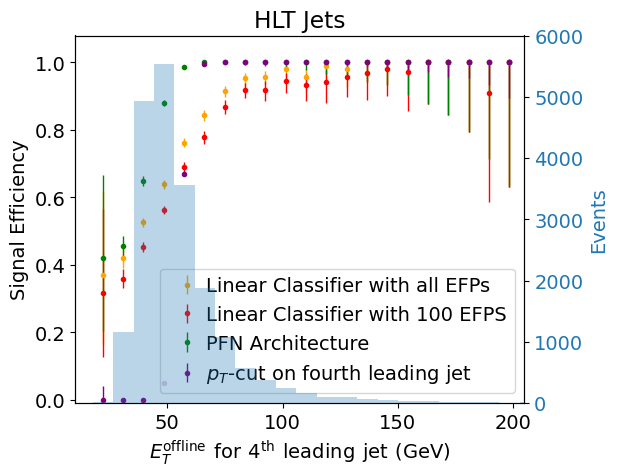

In [ ]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
ax1.set_xlim(10,205)
ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(HLT_energy+4.2, HLT_signal_efficiency, yerr=[HLT_err_low, HLT_err_upp],
             fmt='.', elinewidth=1, color='orange', label='Linear Classifier with all EFPs')
ax1.errorbar(EFPs100_energy+4.2, EFPs100_signal_efficiency, yerr=[EFPs100_err_low, EFPs100_err_upp],
             fmt='.', elinewidth=1, color='red', label='Linear Classifier with 100 EFPS')
ax1.errorbar(energy_pfn+4.2, signal_efficiency_pfn, yerr=[err_low_pfn, err_upp_pfn],
             fmt='.', elinewidth=1, color='green', label='PFN Architecture')
ax1.errorbar(baseline_energy+4.2, baseline_signal_efficiency, yerr=[baseline_err_low, baseline_err_upp],
             fmt='.', elinewidth=1, color='purple', label=(r'$p_T$-cut on fourth leading jet'))

ax2 = ax1.twinx()
ax1.set_ylim(-0.01,1.08)
ax2.set_ylim(0,6000)
ax2.set_ylabel('Events', color= colors[4])
ax2.hist(signal_energies, bins=np.linspace(0.1,300,35), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
#ax1.legend(alignment='left')
ax1.legend(loc='lower right',handletextpad=0)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('HLT Jets')
plt.show()

## Invariant mass

In [ ]:
HLT_jets_lda_mass = np.load('HLT_jets_lda_mass.npz')
HLT_energy = HLT_jets_lda_mass['energy']
HLT_signal_efficiency = HLT_jets_lda_mass['signal_eff']
HLT_err_low = HLT_jets_lda_mass['err_low']
HLT_err_upp = HLT_jets_lda_mass['err_upp']

In [ ]:
EFPs100_lda_mass = np.load('HLT_jets_100_EFPs_mass.npz')
EFPs100_energy = EFPs100_lda_mass['energy']
EFPs100_signal_efficiency = EFPs100_lda_mass['signal_eff']
EFPs100_err_low = EFPs100_lda_mass['err_low']
EFPs100_err_upp = EFPs100_lda_mass['err_upp']

In [ ]:
baseline_mass = np.load('baseline_mass_HLT.npz')
baseline_energy = baseline_mass['energy']
baseline_signal_efficiency = baseline_mass['signal_eff']
baseline_err_low = baseline_mass['err_low']
baseline_err_upp = baseline_mass['err_upp']

In [ ]:
HLT_jets_pfn_mass = np.load('HLT_jets_pfn_mass.npz')
energy_pfn = HLT_jets_pfn_mass['energy']
signal_efficiency_pfn = HLT_jets_pfn_mass['signal_eff']
err_low_pfn = HLT_jets_pfn_mass['err_low']
err_upp_pfn = HLT_jets_pfn_mass['err_upp']

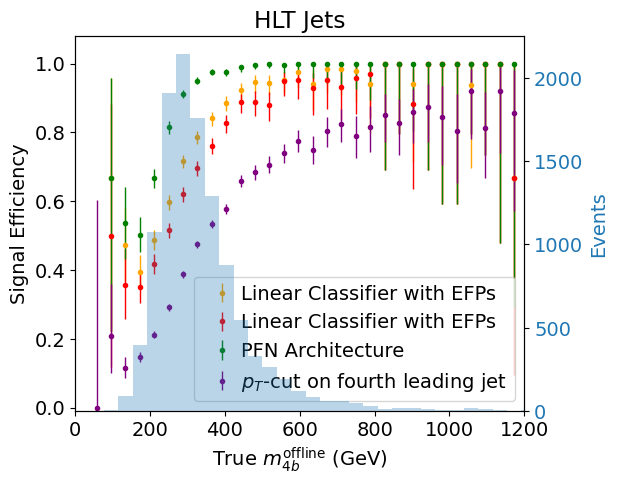

In [ ]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(HLT_energy+18.75, HLT_signal_efficiency, yerr=[HLT_err_low, HLT_err_upp],
             fmt='.', elinewidth=1, color='orange', label='Linear Classifier with EFPs')
ax1.errorbar(EFPs100_energy+18.75, EFPs100_signal_efficiency, yerr=[EFPs100_err_low, EFPs100_err_upp],
             fmt='.', elinewidth=1, color='red', label='Linear Classifier with EFPs')
ax1.errorbar(energy_pfn+18.75, signal_efficiency_pfn, yerr=[err_low_pfn, err_upp_pfn],
             fmt='.', elinewidth=1, color='green', label='PFN Architecture')
ax1.errorbar(baseline_energy+18.75, baseline_signal_efficiency, yerr=[baseline_err_low, baseline_err_upp],
             fmt='.', elinewidth=1, color='purple', label=(r'$p_T$-cut on fourth leading jet'))

ax2 = ax1.twinx()
ax1.set_ylim(-0.01,1.08)
#ax2.set_ylim(0,6000)
ax1.set_xlim(0,1200)
ax2.set_ylabel('Events', color= colors[4])
ax2.hist(signal_mass, bins=np.linspace(0.1,1500,40), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.legend(loc='best', handletextpad=0)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('HLT Jets')
plt.show()